In [5]:
import os
import ee
import rasterio
from geotessera import GeoTessera
import geopandas as gpd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os
import rasterio
from rasterio.transform import Affine
import numpy as np
import xarray as xr
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler, MinMaxScaler
import geemap.foliumap as geemap
import rioxarray
import folium
import numpy as np
import xarray as xr

ee.Authenticate()
ee.Initialize(project="vital-wavelet-217112")

gt = GeoTessera()

RASTERS_PATH = "./dataset/rasters"
os.makedirs(RASTERS_PATH, exist_ok=True)

In [18]:
tile = gpd.read_file("./dataset/tile_C51L41_WGS84.gpkg")
if tile.crs != "EPSG:4326":
    tile = tile.to_crs(epsg=4326)
min_lon, min_lat, max_lon, max_lat = tile.total_bounds
center = [(min_lat + max_lat) / 2, (min_lon + max_lon) / 2]
bbox = list([ float(b) for b in tile.total_bounds ])
bbox

[-61.25000000000001, -8.25, -61.0, -7.999999999999998]

In [29]:
year = 2024
label = "class"
label_column = "CLASS"

samples = gpd.read_file("./dataset/Deter20_24_C51L41.gpkg")
samples = samples[samples["DATE"].dt.year == year]
# samples = samples[samples[label_column] == label]
if samples.crs != "EPSG:4326":
    samples = samples.to_crs(epsg=4326)
samples['id'] = samples['idx']
samples = samples.drop(columns=["id", "DATE"])

In [32]:
year = 2024
label = "Deter_Deg_CsG"
label_column = "class_multisource"

samples = gpd.read_file("./dataset/Aut_C51L41_preclass.gpkg")
samples = samples[samples["date_multisource"].dt.year == year]
samples = samples[samples[label_column] == label]
if samples.crs != "EPSG:4326":
    samples = samples.to_crs(epsg=4326)
samples['id'] = samples['idx']
samples = samples.drop(columns=["idx", "date", "date_multisource"])

In [27]:
min_lon, min_lat, max_lon, max_lat = bbox
tiles_to_fetch = gt.registry.load_blocks_for_region(bounds = bbox, year = year)
tiles = gt.fetch_embeddings(tiles_to_fetch)
tiles

<generator object GeoTessera.fetch_embeddings at 0x740a397afe20>

In [19]:
for tile_id, coord_1, coord_2, tile_arr, crs, transform in lista_embeddings:
    if tile_arr.ndim == 3:
        if tile_arr.shape[-1] in [64, 128, 256]:
            raster_data = tile_arr.transpose(2, 0, 1)
        else:
            raster_data = tile_arr
    elif tile_arr.ndim == 2:
        raster_data = tile_arr[np.newaxis, ...]
    else:
        raise ValueError(f"Unexpected array shape: {tile_arr.shape}")
    
    channels, height, width = raster_data.shape
    output_filename = f"{RASTERS_PATH}/tessera_tile_{tile_id}_{year}.tif"
    
    with rasterio.open(
        output_filename,
        mode      = "w",
        driver    = "GTiff",
        height    = height,
        width     = width,
        count     = channels,
        dtype     = raster_data.dtype,
        crs       = crs,
        transform = transform,
        compress  = "lzw"
    ) as dst:
        dst.write(raster_data)

    print(f"Saved: {output_filename} ({channels} bands, {width}x{height} px)")

Saved: ./dataset/rasters/tessera_tiles/tessera_tile_2024_2024.tif (128 bands, 1107x1111 px)
Saved: ./dataset/rasters/tessera_tiles/tessera_tile_2024_2024.tif (128 bands, 1107x1111 px)
Saved: ./dataset/rasters/tessera_tiles/tessera_tile_2024_2024.tif (128 bands, 1107x1112 px)
Saved: ./dataset/rasters/tessera_tiles/tessera_tile_2024_2024.tif (128 bands, 1108x1112 px)
Saved: ./dataset/rasters/tessera_tiles/tessera_tile_2024_2024.tif (128 bands, 1107x1111 px)
Saved: ./dataset/rasters/tessera_tiles/tessera_tile_2024_2024.tif (128 bands, 1107x1111 px)
Saved: ./dataset/rasters/tessera_tiles/tessera_tile_2024_2024.tif (128 bands, 1108x1111 px)
Saved: ./dataset/rasters/tessera_tiles/tessera_tile_2024_2024.tif (128 bands, 1108x1112 px)
Saved: ./dataset/rasters/tessera_tiles/tessera_tile_2024_2024.tif (128 bands, 1107x1111 px)
Saved: ./dataset/rasters/tessera_tiles/tessera_tile_2024_2024.tif (128 bands, 1107x1111 px)
Saved: ./dataset/rasters/tessera_tiles/tessera_tile_2024_2024.tif (128 bands, 11

In [8]:
# Carrega múltiplos arquivos com suporte a Dask
da_tessera = xr.open_mfdataset(
    f"{RASTERS_PATH}/tessera_tile_*_2024.tif",
    engine="rasterio",
    chunks="auto"
)
da_tessera

<xarray.Dataset> Size: 631MB
Dimensions:      (band: 128, x: 1108, y: 1112)
Coordinates:
  * band         (band) int64 1kB 1 2 3 4 5 6 7 ... 122 123 124 125 126 127 128
  * x            (x) float64 9kB 7.204e+05 7.205e+05 ... 7.315e+05 7.315e+05
  * y            (y) float64 9kB 9.126e+06 9.126e+06 ... 9.115e+06 9.115e+06
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 631MB dask.array<chunksize=(128, 236, 1108), meta=np.ndarray>

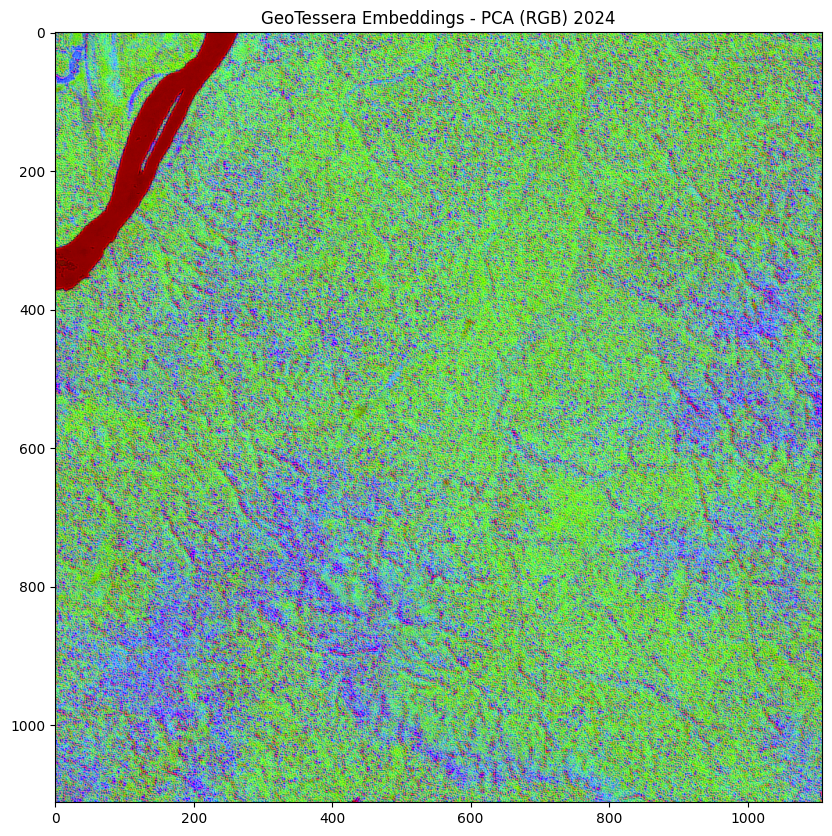

In [23]:
# 1. Carrega os dados do Dask para a memória e reorganiza os eixos
# Shape original: (band: 128, y: 1112, x: 1108)
da_data = da_tessera['band_data']

# Reordena para (y, x, band) e converte em array 2D: (N_pixels, 128)
y_coords = da_data.y.values
x_coords = da_data.x.values
n_bands, n_y, n_x = da_data.shape

# Carrega os dados na memória (computa dask array)
flat_data = da_data.values.transpose(1, 2, 0).reshape(-1, n_bands)

# 2. Trata valores NaN / NoData (se existirem)
valid_mask = ~np.isnan(flat_data).any(axis=1)
pca_result = np.full((n_y * n_x, 3), np.nan, dtype=np.float32)

# 3. Executa o PCA para as 3 primeiras componentes principais
pca = PCA(n_components=3)
transformed = pca.fit_transform(flat_data[valid_mask])

# 4. Normalização Min-Max Robusta (2% a 98%) para o intervalo [0, 1]
p2 = np.percentile(transformed, 2, axis=0)
p98 = np.percentile(transformed, 98, axis=0)
transformed_scaled = (transformed - p2) / (p98 - p2)
transformed_scaled = np.clip(transformed_scaled, 0.0, 1.0)

# Preenche a matriz de saída
pca_result[valid_mask] = transformed_scaled

# 5. Reshape de volta para a grade espacial: (3, y, x)
pca_rgb_array = pca_result.reshape(n_y, n_x, 3).transpose(2, 0, 1)

# 6. Cria o novo xarray.DataArray preservando CRS e coordenadas
da_rgb = xr.DataArray(
    pca_rgb_array,
    dims=['band', 'y', 'x'],
    coords={
        'band': ['R', 'G', 'B'],
        'y': y_coords,
        'x': x_coords,
        'spatial_ref': ds.spatial_ref
    },
    attrs={
        'long_name': 'PCA RGB Composition from 128-band Embeddings',
        'explained_variance_ratio': pca.explained_variance_ratio_
    }
)

# 7. Copia metadados de projeção espacial (rioxarray)
if hasattr(da_tessera, 'rio'):
    da_rgb.rio.write_crs(da_tessera.rio.crs, inplace=True)
    da_rgb.rio.write_transform(da_tessera.rio.transform(), inplace=True)

# 8. Salva o raster RGB com PCA
tif_pca_path = f"{RASTERS_PATH}/tessera_tile_{year}_pcargb.tif"
da_rgb.rio.to_raster(tif_pca_path, dtype="float32")

da_rgb = rioxarray.open_rasterio(tif_pca_path, chunks="auto")

plt.figure(figsize=(10, 10))
plt.imshow(da_rgb.values.transpose(1, 2, 0))
plt.title(f"GeoTessera Embeddings - PCA (RGB) {year}")
plt.show()


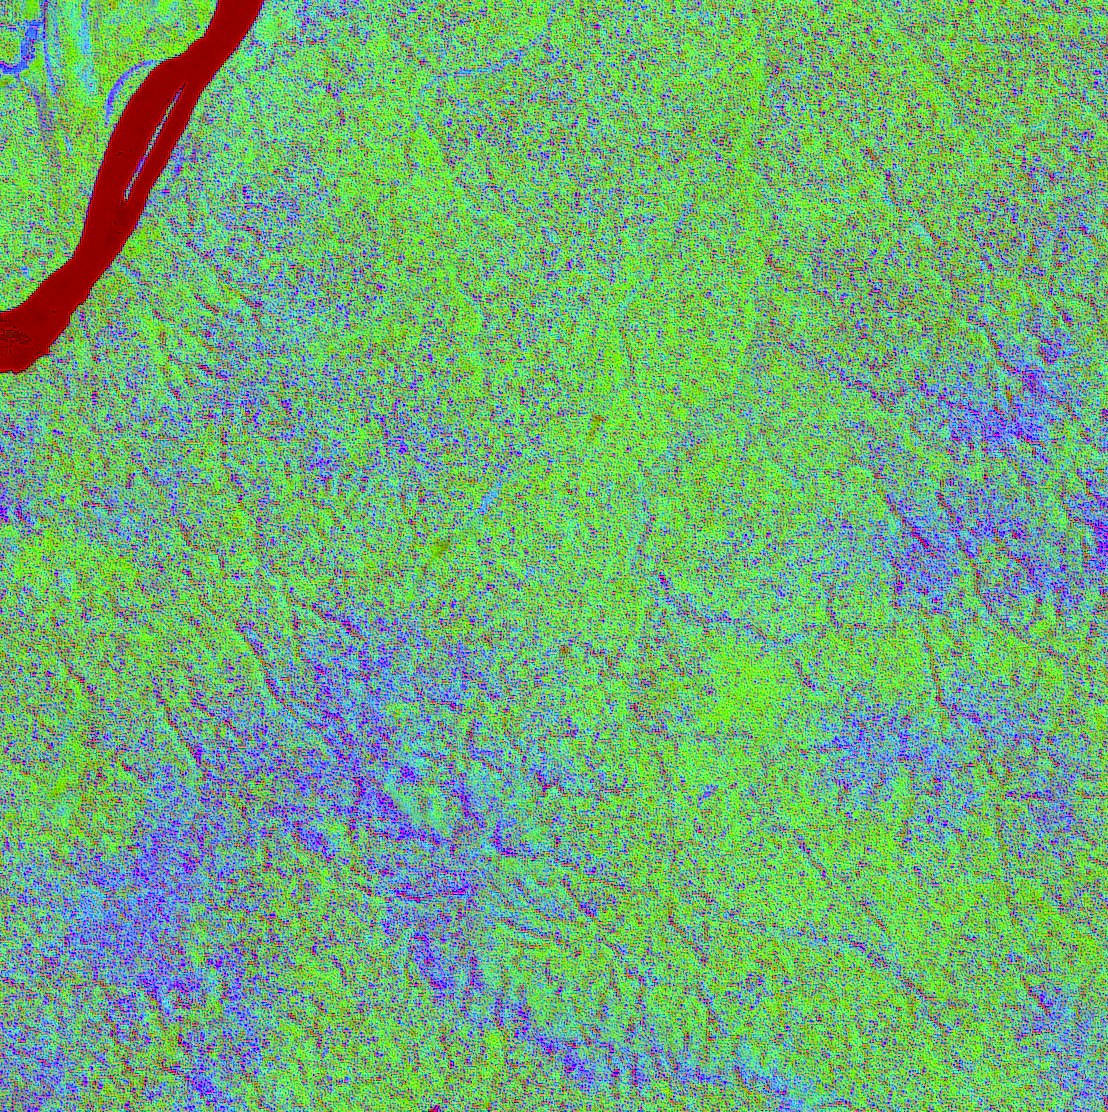

In [34]:
# 3. Cria o mapa interativo
Map = folium.Map(location=center, zoom_start=12, tiles="OpenStreetMap")

# 4. Adiciona a camada de satélite como base opcional
folium.TileLayer(
    tiles="https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}",
    attr="Google Satellite",
    name="Google Satellite"
).add_to(Map)

folium.raster_layers.ImageOverlay(
    image=np.clip(da_rgb.values.transpose(1, 2, 0), 0.0, 1.0),
    bounds=[[min_lat, min_lon], [max_lat, max_lon]],
    opacity=1,
    name="Tessera PCA RGB"
).add_to(Map)

folium.GeoJson(
    tile,
    name="Tile C51L41",
    style_function=lambda feature: {
        "fillColor": "#ff7800",
        "color": "#000000",       # Cor da borda
        "weight": 2,              # Espessura da borda
        "fillOpacity": 0.2,       # Transparência do preenchimento
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[col for col in tile.columns if col != "geometry"][:3],  # Mostra até 3 colunas de atributos
        localize=True
    )
).add_to(Map)

folium.GeoJson(
    samples,
    name=f"DETER Samples Distúrbios {label}",
    style_function=lambda feature: {
        "fillColor": "#ff7800",
        "color": "#000000",       # Cor da borda
        "weight": 2,              # Espessura da borda
        "fillOpacity": 0.2,       # Transparência do preenchimento
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[col for col in samples.columns if col != "geometry"][:3],  # Mostra até 3 colunas de atributos
        localize=True
    )
).add_to(Map)

folium.LayerControl().add_to(Map)

Map